# Test installations and features for Praktikum Bioinformatik
This notebook is an example to make sure all necessary imports work as expected

In [1]:
# Let's start with python
import sys
print('hello world')

hello world


In [2]:
[user] = !whoami
print(f'Hello and welcome \"{user}\" to the practical course on RNA and protein structures!')

Hello and welcome "erik" to the practical course on RNA and protein structures!


In [3]:
# And some bash code, what's in your directory?
!ls

biohazard.png  input	 myrna.fa     PrakBioinfSS2026_students.ipynb  software
data	       mypython  myrna_ss.ps  Praktikum.ipynb


### Embedding images:

If you provide an image called `biohazard.png` you can use the follwoing code to display it:


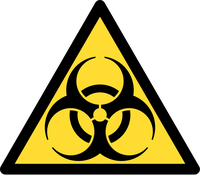

In [4]:
# and one version to display images ...
from PIL import Image # from the Pillow library
# open the image
with Image.open('biohazard.png') as im:
    # identify width and height
    w,h = im.width, im.height
    # get scaling factor to obtain an image with 200 width
    scale = 200 / w
    # rescale image
    new_w, new_h = int(w * scale), int(h * scale)
    im = im.resize((new_w, new_h), Image.LANCZOS)
    # display the image
    display(im)

## Alright, let's test ViennaRNA Python bindings

In [5]:
import RNA
import random

print(f'ViennaRNA version is {RNA.__version__}')

def randseq(l):
    """ Returns a random sequence of length l. """
    rseq = []
    for _ in range(l):
       rseq.append(random.choice('ACGU'))
    return ''.join(rseq)

def randseq(l):
    """ Returns a random sequence of length l. """
    # A more pythonic implementation using list comprehension ...
    return ''.join([random.choice('ACGU') for _ in range(l)])

seq = randseq(50)
md = RNA.md()
fc = RNA.fold_compound(seq, md)
ss, en = fc.mfe()
print(seq)
print(f'{ss} {en:6.2f}')

ViennaRNA version is 2.7.2
GCGACAUACAACGAUCUGGGAUCGGCCAGCGUGGCGUGGCAACGUCCUAG
...............(((((((..((((((...)).))))...))))))) -14.70


# Basic Setup for the course (Follow these steps!)

## 1) Commandline conda environment

### At the first time
**here, we need to create a conda environment, don't we?**

 - Open a terminal (e.g. via the '+' button -> Terminal)
 - type "conda init"
 - close the terminal
 
### After the first time
 - Open a terminal (e.g. via the '+' button -> Terminal)
 - type `conda activate praktikum`

## 2) Make your Work environment 
 - Create a directory called `WORK`
 - Close this notebook and move it into that directory.
 
## 3) Make a simple Python library 
(You should now be in the directory `WORK` and have opened this notebook there.)
 - Create a directory called `mypython`
 - Create a file called `mypython/__init__.py`
 - Create a file called `mypython/utils.py`
 - Take your preferred function definition of `randseq()` (and the necessary library imports) from the cell above and paste it in the file `mypython/utils.py`
 - proceed executing the following cell 


In [6]:
# You need to follow the steps above before this works
from mypython.utils import randseq
print(randseq(50))

GUAUAGCCGACGGUGGAGCGAGAACUUUGCCUGCGGAAGCCUGAUCCGGC


In the previous cell, we build a prototype of a personal Python library. Notebooks are a great way to communicate results, they can also be very helpful for developing code, but they are not a proper place to keep your code. For example, if you want to start a new project, you don't want to copy all the code cells from one notebook to the next, then remember in which order to execute them, etc. Whenever you are happy with a function you coded, make sure to add it to your library and document what it is doing, so you will be able to use it again in the future. (When you add to your library, you may have to restart the kernel to use the code.)

If you did not understand what you were doing in any of the previous tasks, ask! All those steps should become a routine in daily work with Python and Jupyter notebooks. 

__You are all set__.


# Introduction

From this point on, notebooks will probably be an integral part of your work during this practical course, so try your best to **keep them tidy, concise and easy to read**.
A good way to think about this notebook is that you want to read (and understand) it in a year from now. Everything you might have forgotten by then, should be in here!

For example:
 - if you write a large piece of code, then move it to the `mypython` library, document it there, and import it
 - if you take notes during literature research, then use the "Markdown" cell format, and use links or citations to reference your findings. 
 - Do **not** copy-paste large pieces of tutorials into this notebook, keep your notes to the point, and link them if you found them helpful
 
In principle, a notebook should be executable by running all cells *in order*. However, nobody except you will run your notebook. Please note, that you can export this notebook at any time, e.g. into a PDF through the menu "File" -> "Export Notebook As ..." -> "PDF".

# 1. Linux terminal and Jupyter lab notes

Checkout the following pages if you are not comfortable working with Linux:
 - https://ryanstutorials.net/linuxtutorial/
 - https://ubuntu.com/tutorials/command-line-for-beginners#1-overview

## Notes for terminal use (extend if needed):
* `$ ls`: look at the contents of the current directory
* `$ cp origin destination`: copy a file from origin to destination
* `--help`: almost always gives a documentation of commandline parameters
* ... further notes to yourself

## Notes for Jupyter notebooks (extend if needed):
* you can change the type of cell from "markdown, code, raw"
* `code` cells may contain Python code as well as terminal commands
* Terminal commands need to be started with an exclamation mark `!`
* ... further notes to yourself

In [7]:
# You can use "!" in a code cell to execute a command in the terminal.
import mypython.utils as my

# create a random sequence of length 50
seq = my.randseq(50)
# store the sequence into a file 'myrna.fa'
!echo -e ">myrna\n$seq" > myrna.fa 
# list directory content
!ls
# print the content of the file
!cat myrna.fa

biohazard.png  input	 myrna.fa     PrakBioinfSS2026_students.ipynb  software
data	       mypython  myrna_ss.ps  Praktikum.ipynb
>myrna
GCUUUUUUGGUUCUCUUUUACUUAUUAGCCCACCGCGGCGUAGGAUCUUG


### Another example

>myrna
GCUUUUUUGGUUCUCUUUUACUUAUUAGCCCACCGCGGCGUAGGAUCUUG
........((((((.............(((......)))..))))))... ( -5.80)


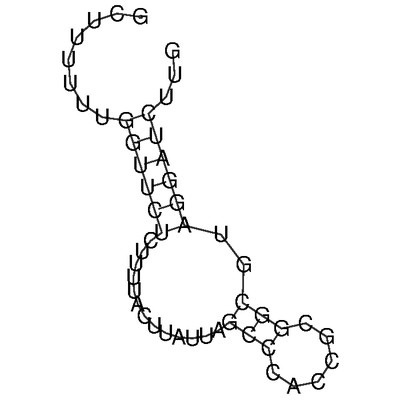

In [8]:
!cat myrna.fa | RNAfold
from PIL import Image # from the Pillow library
Image.open('myrna_ss.ps').resize((400,400), Image.LANCZOS)

# 2. Literature research on RNA modification and the effect on RNA secondary structure

## Kierzek et al. (2022) - Secondary structure prediction for RNA sequences including $N^6$-methyladenosine
[Link to the publication](https://doi.org/10.1038/s41467-022-28817-4)

 - What did they do?
 - What data do they provide?
 - ...

**Here more content**

## Potentially relevant questions for RNA structure prediction with modified nucleotides
- How may a modification alter structure stability?
- Which types of RNA sequences contain modified bases?
- Which parts of RNA sequences are modified (UTRs, CDS, etc.)?
- What data is required for structure prediction with modified bases?
- What data is available?
- ...?
- Find out how and/or where m6A modification sites in actual RNA transcripts (human, mouse, etc) can be obtained from.
- Prepare an outline for a (statistical) analysis of structure/accessibility changes in RNA transcripts due to post-transcriptional RNA modification.

Always keep a publication refernce for any approach or data source you are about to use!

The following questions may be helpful:
 - How can accessibility of particular sites of an RNA be related to its the function?
 - What is the input and output of your analysis?
 - What (kind of) tools and data do you require?
 - Where to get relevant data from (sequences, sequence annotation, modification sites)?
 - How do you have to prepare the input data?
 - How do you present the output?

# 3. Example sequence: MALAT1 hairpin

## Compute suboptimal structures with and without m6A modification

Run the code below to enumerate all suboptimal structure within an interval $\delta = 3kcal \cdot mol^{-1}$ around the MFE. The first prediction is for the unmodifed sequence, the second for the one where position A22 is methylated to an m6A. Note, that for adding the list `m6A sites` to the prediction we use the convenience method `sc_m6A()` attached to fold_compound objects. This will automatically take care to prepare and attach the required constraints to the prediction algorithms.

- Try making sense of the output
- Compare the results to the ones provided in the Kierzek et al. 2022 publication
- Attempt to change the code such that it only prints the first (MFE) structure and the next best structure where the `HNRNPC` protein binding site is completely unstructured


In [9]:
# the MALAT1 hairpin sequence
malat1_hp = "AACUUAAUGUUUUUGCAUUGGACUUUGAGUUA"

# The position of m6A within the MALAT1 hairpin sequence (1-based)
m6A_sites = [22]

print(malat1_hp)

delta = 4. # delta around MFE in kcal/mol

# create a fold_compound object for structure prediction
fc = RNA.fold_compound(malat1_hp)
# loop over all structures with 3kcal/mol around MFE
for s in fc.subopt(int(delta * 100.)):
    print("{} {:6.2f}".format(s.structure, s.energy))

# add a list of m6A positions (1-based)
if m6A_sites:
    fc.sc_mod_m6A(m6A_sites)

print(malat1_hp)
# Again, loop over all structures with 3kcal/mol around MFE
for s in fc.subopt(int(delta * 100.)):
    print("{} {:6.2f}".format(s.structure, s.energy))

AACUUAAUGUUUUUGCAUUGGACUUUGAGUUA
(((((((.((((.......)))).))))))).  -6.70
.((((((.((((.......)))).))))))..  -5.80
((((((..((((.......))))..)))))).  -5.60
(((((((.(((.........))).))))))).  -5.10
.(((((..((((.......))))..)))))..  -4.70
..(((((.((((.......)))).)))))...  -4.50
.((((((.(((.........))).))))))..  -4.20
((((((..(((.........)))..)))))).  -4.00
(((((((..(((.......)))..))))))).  -3.90
...(((((((....)))))))...........  -3.90
....((((((....))))))((((...)))).  -3.70
(((((((.((...........)).))))))).  -3.60
(((((((.(((.(......)))).))))))).  -3.50
(((((((.((.((......)))).))))))).  -3.50
(((((((.(.(((......)))).))))))).  -3.50
(((((...((((.......))))...))))).  -3.50
..((((..((((.......))))..))))...  -3.40
....((((((....))))))............  -3.40
((((((((((....)))).......)))))).  -3.10
.(((((..(((.........)))..)))))..  -3.10
((((((((((....))))).......))))).  -3.00
(((((((.((.(.......).)).))))))).  -3.00
.((((((..(((.......)))..))))))..  -3.00
((((((((((....))).......))))))).  -2.90
(((((((

In [10]:
# compute unpaired probabilities/accessibility for UUUUU binding motif
import math

fc = RNA.fold_compound(malat1_hp)
pp, dG1 = fc.pf()
for i in range(10, 15):
    fc.hc_add_up(i)
pp, dG2 = fc.pf()
oe = dG2 - dG1
pup = math.exp(-oe / (RNA.exp_param().kT / 1000))

# reset hard constraints to defaults
fc.hc_init()
# add m6A sites
fc.sc_mod_m6A(m6A_sites)

pp, dG1 = fc.pf()
for i in range(10, 15):
    fc.hc_add_up(i)
pp, dG2 = fc.pf()
oe_mod = dG2 - dG1
pup_mod = math.exp(-oe_mod / (RNA.exp_param().kT / 1000))

print(f"Accessibility unmodified: {pup:1.4f} ({oe:1.2f} kcal/mol opening energy)")
print(f"Accessibility with m6A:   {pup_mod:1.4f} ({oe_mod:1.2f} kcal/mol opening energy)")


Accessibility unmodified: 0.0026 (3.66 kcal/mol opening energy)
Accessibility with m6A:   0.0165 (2.53 kcal/mol opening energy)


## Computing accessibilities

Below is a function that takes as input an RNA sequence, and optionally a (list of) footprint size(s),
a windowsize `w`, a maximum base pair span `L` and a list of `m6A_sites` to compute accessibilities, i.e.
probabilities to be unpaired, along the lines of Bernhart et al., 2011.

Accessibilities are split into 4 different kinds of loops the unpaired regions may reside in.

Take the function below and add it to your `mypython` package. For that purpose, simply
create a new file `mypython/algorithms.py` and place the `looptypes` dictionary and `accessibility()`
function into this file. Do not forget to `import RNA` at the beginning of the file.

In [11]:
# A dictionary with all types of loops distinguished in the
# unpaired probability computations of the ViennaRNA Package
looptypes = { RNA.EXT_LOOP : "external",
              RNA.HP_LOOP : "hairpin",
              RNA.INT_LOOP : "internal",
              RNA.MB_LOOP : "multibranch"
}

def accessibility(sequence, footprints = 30, windowsize = 200, L = 150, m6A_sites = None):
    """
    Compute unpaired probabilities for a set of (or single) footprint(s)
    using a sliding-window local RNA secondary structure prediction.

    The function returns a dictionary of unpaired probabilities for
    each footprint. Here, the keys are the individual footprint sizes
    as specified in the input argument 'footprints'. Each of the
    corresponding values is a dictionary again, where the keys are the
    individual loop types the footprint may reside in and the values are
    lists of probabilities where the i-th value is the probability of
    a footprint starting at position i.
    """

    def up_callback(v, v_size, i, maxsize, what, data):
        """
        Store accessibility data callback function
        """
        # only process unpaired probabilities
        if what & RNA.PROBS_WINDOW_UP:
            # mask variable 'what' such that it assumes
            # one of the vaues in 'looptypes'
            what = what & ~RNA.PROBS_WINDOW_UP
            #if i % 100 == 0:
            #    print(i)
            for fp in data.keys():
                # we store data for footprints starting
                # at position i, but 'probs_window()' yields
                # data ending at position i. So we need to
                # compute actual start position of the footprint
                start = i - fp + 1
                if start > 0:
                    dat = data[fp][what][start] = v[fp]

    # store footprints as list of footprint sizes
    fps = footprints if type(footprints) is list else [ footprints ]
    fps = [ int(fp) for fp in fps ]

    # create data structure (dict of dicts of lists) where we will store
    # the computed accessibilities. After filling the data structure, we
    # can obtain the resulting unpaired probabilities for each footprint
    # of size 'fp', starting at position 'i' and residing in loop type
    # 'lt' as:
    # p = data[fp][lt][i]
    data = { k : { lt : [ 0 for i in range(len(sequence) - k + 2) ] for lt in looptypes } for k in fps }

    # create model details and set windowsize and maximum base pair span
    md = RNA.md()
    md.max_bp_span = L
    md.window_size = windowsize

    # create fold_compound for sliding-window computations
    fc = RNA.fold_compound(sequence.upper(), md, RNA.OPTION_WINDOW)

    if m6A_sites:
        fc.sc_mod_m6A(m6A_sites)

    # compute sliding-window probabilities
    fc.probs_window(max(fps),
                    RNA.PROBS_WINDOW_UP | RNA.PROBS_WINDOW_UP_SPLIT,
                    up_callback,
                    data)

    return data

### Run the accessibility function for the full-length MALAT1 sequence

First, we need to load the MALAT1 RNA sequence from a FASTA file. For that purpose, we use [Bio.SeqIO](https://biopython.org/wiki/SeqIO) from BioPython. Here, we simply assume that there is only one record within the FASTA file...

The FASTA sequence file itself can be obtained either from [NCBI nucleotide database](https://ncbi.nlm.nih.gov/nuccore) or download it from the Moodle page and upload it to the jupyter server.
Move/Upload the file into a directory `input/NR_002819.4.fasta`.

Running the code below will take some time, since the input sequence is rather long. Note, that we are using the implementation from the `mypython/algorityhms.py` file now.

Add additional footprint sizes that may be of interest.
You may also adjust the windowsize and maximum base pair span L to see how much of a difference these parameters introduce. Note, however, that larger windowsizes also result in higher computation times.

In [16]:
from Bio import SeqIO

malat1_seq = ""

with open("input/NR_002819.4.fasta") as handle:
    for record in SeqIO.parse(handle, "fasta"):
        malat1_seq = str(record.seq)

# convert from DNA to RNA alphabet
malat1_seq.replace("T", "U")

print(malat1_seq)
print(len(malat1_seq))

# algorithm settings
m6A_sites = [2601]
footprints = [5]
windowsize = 150
L = 100

from mypython import algorithms as algo

# run the predictions
data_unmod = algo.accessibility(malat1_seq, footprints, windowsize = windowsize, L = L)
data = algo.accessibility(malat1_seq, footprints, windowsize = windowsize, L = L, m6A_sites = m6A_sites)


CGCAGCCTGCAGCCCGAGACTTCTGTAAAGGACTGGGGCCCCGCAACTGGCCTCTCCTGCCCTCTTAAGCGCAGCGCCATTTTAGCAACGCAGAAGCCCGGCGCCGGGAAGCCTCAGCTCGCCTGAAGGCAGGTCCCCTCTGACGCCTCCGGGAGCCCAGGTTTCCCAGAGTCCTTGGGACGCAGCGACGAGTTGTGCTGCTATCTTAGCTGTCCTTATAGGCTGGCCATTCCAGGTGGTGGTATTTAGATAAAACCACTCAAACTCTGCAGTTTGGTCTTGGGGTTTGGAGGAAAGCTTTTATTTTTCTTCCTGCTCCGGTTCAGAAGGTCTGAAGCTCATACCTAACCAGGCATAACACAGAATCTGCAAAACAAAAACCCCTAAAAAAGCAGACCCAGAGCAGTGTAAACACTTCTGGGTGTGTCCCTGACTGGCTGCCCAAGGTCTCTGTGTCTTCGGAGACAAAGCCATTCGCTTAGTTGGTCTACTTTAAAAGGCCACTTGAACTCGCTTTCCATGGCGATTTGCCTTGTGAGCACTTTCAGGAGAGCCTGGAAGCTGAAAAACGGTAGAAAAATTTCCGTGCGGGCCGTGGGGGGCTGGCGGCAACTGGGGGGCCGCAGATCAGAGTGGGCCACTGGCAGCCAACGGCCCCCGGGGCTCAGGCGGGGAGCAGCTCTGTGGTGTGGGATTGAGGCGTTTTCCAAGAGTGGGTTTTCACGTTTCTAAGATTTCCCAAGCAGACAGCCCGTGCTGCTCCGATTTCTCGAACAAAAAAGCAAAACGTGTGGCTGTCTTGGGAGCAAGTCGCAGGACTGCAAGCAGTTGGGGGAGAAAGTCCGCCATTTTGCCACTTCTCAACCGTCCCTGCAAGGCTGGGGCTCAGTTGCGTAATGGAAAGTAAAGCCCTGAACTATCACACTTTAATCTTCCTTCAAAAGGTGGTAAACTATACCTACTGTCCCTCAAGAGAACACAAGAAGTGCTTTAAGAGGTA

### Plot the result(s)

See also [Python MatPlotLib](https://matplotlib.org/).

What we do below is to create 3 plots for each footprint analyzed. The first two simply show the predicted unpaired probabilities. For the third, we use the `zip(a,b)` and `map()` functions to create a list of pairwise differences between the two data sets (see also https://bradmontgomery.net/blog/pythons-zip-map-and-lambda/). The differences are then plotted while the x-axis is limited to our area of interest, i.e. the region where the HNRNPC protein binds to.

/tmp/ipykernel_4342/3934787533.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


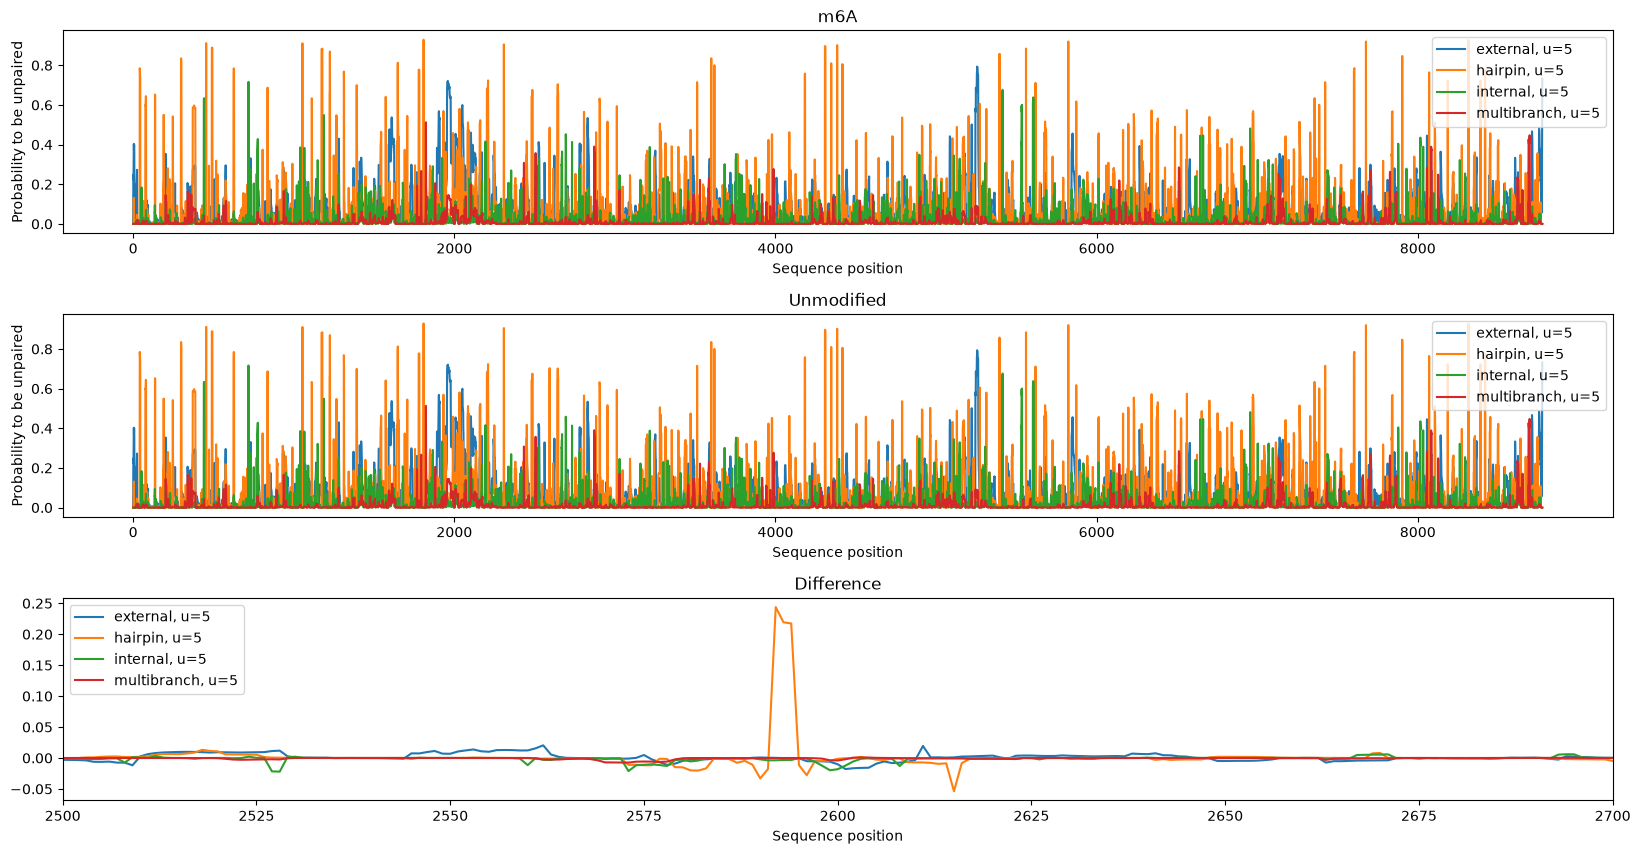

In [13]:
import matplotlib.pyplot as plt
import math


# convert accessibilities to opening energies
#oes = {}
#oes_unmod = {}
#
#for u in footprints:
#    oes[u] = {}
#    oes_unmod[u] = {}
#    for k, v in data[u].items():
#        oes[u][k] = [-math.log(vv) * RNA.exp_param().kT / 1000. if vv > 0 else 0 for vv in v]
#    for k, v in data_unmod[u].items():
#        oes_unmod[u][k] = [-math.log(vv) * RNA.exp_param().kT / 1000. if vv > 0 else 0 for vv in v]

# plot results
for u in footprints:
    fig, axs = plt.subplots(3, sharey = False, figsize = (20, 10))
    for k, v in data[u].items():
        axs[0].plot([i for i in range(len(malat1_seq) + 1 - u + 1)], v, label = "{}, u={:d}".format(looptypes[k], u))
    axs[0].set_title("m6A")
    axs[0].set_xlabel("Sequence position")
    axs[0].set_ylabel("Probability to be unpaired")
    axs[0].legend()
    for k, v in data_unmod[u].items():
        axs[1].plot([i for i in range(len(malat1_seq) + 1 - u + 1)], v, label = "{}, u={:d}".format(looptypes[k], u))
    axs[1].set_title("Unmodified")
    axs[1].set_xlabel("Sequence position")
    axs[1].set_ylabel("Probability to be unpaired")
    axs[1].legend()

    # create a dictionary of lists where the keys are the different loop types we distinguish
    d_diff = {}
    for k in data[u]:
        d_diff[k] = [v for v in map(lambda pair: pair[1] - pair[0], zip(data[u][k], data_unmod[u][k]))]

    for k, v in d_diff.items():
        axs[2].plot([i for i in range(len(malat1_seq) + 1 - u + 1)], v, label = "{}, u={:d}".format(looptypes[k], u))
    axs[2].set_title("Difference")
    axs[2].set_xlabel("Sequence position")
    axs[2].legend(loc="upper left")
    axs[2].set_xlim([2500, 2700])
    fig.subplots_adjust(hspace=0.4)
    fig.show()


# 4. Further analysis below

The next steps will be to obtain a larger collection of RNA sequences together with their respective m6A modification sites.

Accessibilities for these sequences can then be predicted and an overall statistics may give us an idea of the changes in accessibility due to m6A modifications within that larger set of sequences, e.g. the whole transcriptome. One can further analyze different parts of mRNA transcripts seperately, e.g. 5'UTR, 3'UTR and coding sequences.

Sketch the analysis and data required for that!
Note, that we most likely require special tools to combine and prepare all the input data we can get from elsewhere. See, for instance, the [BEDTools](https://bedtools.readthedocs.io/en/latest/index.html) Package that provides a Swiss army knife for working with sequence annotation data.

Once the analysis is sketched, your ideas can be presented and the actual implementation can be derived together.

## Preparation of the hg38 input annotation files

Genome annotation file one can download from the NCBI database does **not** include `UTR` annotation. To generate this data,
one has to resort to a additional program that reads in all the transcript data stored in the annotation file and relates
these transcript regions with the exons and coding sequences it is composed of. Once the coding sequence part of an mRNA
transcript are know, it is obvious, which parts of the transcript remain untranslated (UTR). Here, you may want to use a
[Python script written by Stephen Floor](https://github.com/stephenfloor/extract-transcript-regions). To use it, you need to
*clone* the code repository from Github somewhere into your Jupyter work directory. For instance, you might want to create
a `software` directory to keep your working directory clean and clone the script there...

The required Linux Terminal commands for that are:
```
$ cd WORK
$ mkdir software
$ cd software
$ git clone https://github.com/stephenfloor/extract-transcript-regions.git
```
Now, we will use the `extract_transcript_regions.py` script to generate
[BED12 files](https://en.wikipedia.org/wiki/BED_\(file_format\)) files for the UTRs and coding and noncoding transcripts.
We require those to obtain the corresponding transcript sequences from the full genome later on. Let us write all output
of that script into a directory `hg38` with a file prefix `hg38`:
```
$ mkdir hg38
$ cd hg38
$ WORK/software/extract-transcript-regions/extract_transcript_regions.py --gtf -i hg38_anotation.gtf -o hg38
$ ls -l
```
This should produce the files `hg38_3utr.bed`, `hg38_5utr_start.bed`, `hg38_codingexons.bed`, `hg38_exons.bed`,
`hg38_noncodingexons.bed`, `hg38_5utr.bed`, `hg38_cds.bed`, `hg38_codingintrons.bed`, `hg38_introns.bed`, and
`hg38_noncodingintrons.bed`.

Have a look into these files to get an idea what data they contain and how the data is structured.

**You can of course use the above UTR and transcript extraction tool for all the genomes you want to analyze**


### Extracting FASTA sequence data based on annotated regions

In cases where one has an annotation file with sequence positions of interest, e.g. 5'UTRs,
and one wants to obtain the corresponding sequences from the genome, the `bedtools getfasta`
program becomes very handy, see also
[the documentation](https://bedtools.readthedocs.io/en/latest/content/tools/getfasta.html)

Note, that in almost all cases you want to use the `-s` option to force strandedness, i.e.
obtain the sequences from the correct strand within the genome. Also note, if you have BED12
files with transcripts that consists of exon blocks, you want to use the `-split` option in
addition.

## Mapping global intersected m6A sites to local positions within individual transcripts

The [RMBase database](https://rna.sysu.edu.cn/rmbase/download.php) provides BED-formatted
annotation files for the m6A positions of various genomes. However, those positions are
**global**, i.e. they relate to the numbering within each chromosome, not the particual
transcripts.

To still make use of the data, we need to transform these global coordinates into **local**
coordinates within our sequences. This is not too easy but doable with the help of
`bedtools intersect` and a little Python programming. The general idea here is that first,
we need to find out which m6A site overlaps with what RNA transcript. This can be done with
the [intersect](https://bedtools.readthedocs.io/en/latest/content/tools/intersect.html)
tool and using the transcript annotation files, e.g. `5UTR.bed`, and the BED file provided
by RMBase. Note once again, that you need strandedness (`-s` flag) and the `-split` option
to only print those m6A sites that are in the exonic part of the transcript region.

**There is another obstacle, though:** To make `bedtools` work correctly, the chromosome
identifiers in both annotation files should be identical. However, the annotation file we
downloaded from NCBI uses Accession numbers of the form `NT_xxxxxx.y` whereas the annotation
from RMbase uses `chr1`, `chr2`, etc. This needs to be corrected first!

### Let's get started

To obtain local coordinates of m6A sites within each transcript we want to analyze, we need to do two things:
- map the m6A sites globally to the transcripts
- transform the global coordinates into local coordinates

### Finally, got through the transcriptome sequences and obtain the corresponding (local) m6A sites

In the part below, we go through all transcripts, lookup whether we have m6A data for them, and then perform a sanity-check whether all m6A positions are actually `A`s. (Here, it might be advisable to also check for the DRACH motif)


